
# Simulación Monte Carlo para Presupuesto de Costos

Este notebook incluye:
- Modelo determinístico de costos
- Definición de distribuciones de probabilidad
- Simulación Monte Carlo (5000 iteraciones)
- Interpretación de resultados
- Visualización
- Análisis de sensibilidad
- Conclusiones


In [223]:
#Importar librerías: matplotlib, random y numpy
import matplotlib.pyplot as plt
import random
import numpy as np
%matplotlib inline

## 1. Modelo determinístico
El presupuesto total (costo total determinístico) de un proyecto de una obra en construcción es la suma de los costos de materiales, mano de obra y transporte.

### Presupuesto total
costo_total = materiales + mano_obra + transporte

In [224]:
# se determina el número de simulaciones, el número máximo que se tiran los dados (para obtener la muestra de los costos)
num_simulations = 5000
max_num_rolls = 1000
#bet = 1

# Costos fijos (determinísticos): materiales, mano de obra, transporte, y costo de referencia
materiales = 0
mano_obra = 0
transporte = 0
costo_referencia = 8500

## 2. Definición de distribuciones
Se va a usar la distribución triangular para los costos fijos

In [225]:
#función para obtener una muestra de todos los costos fijos determínisticos
np.random.seed(42)
def roll_dice():
   # Definición de distribuciones triangulares
    materiales = np.random.triangular(left=4500, mode=5000, right=6000)
    mano_obra = np.random.triangular(left=2500, mode=3000, right=3800)
    transporte = np.random.triangular(left=800, mode=1000, right=1300)

    return materiales, mano_obra, transporte

In [226]:
# vamos a usar la funcion roll_dice y obtener una muestra de los costos
a = roll_dice()

print(a[0], a[1], a[2])

5031.398006542958 3573.5996436979676 1099.498357292791


## 3. Simulación Monte Carlo
Se establece el número de simulaciones en 5000 y el valor máximo del dado en 1000. Asimismo, se declara la variable `end_balance = []`.


In [227]:
num_simulations = 5000
max_num_rolls = 1000
#bet = 1

end_balance = []

Se hace un For para hacer la simulación de 5000 iteraciones, y se tira los dados en cada iteración para obtener los costos fijos del proyecto y la suma se agrega a la lista balance en cada iteración. 

La gráfica muestra el comportamiento de las simulaciones del costo total a lo largo de las muestras generadas. Se observa una variación constante entre aproximadamente $8,000 y $11,000, lo que indica incertidumbre en los costos del proyecto.

La mayor concentración de valores parece ubicarse alrededor de los $9,000 a $9,800, sugiriendo que ese rango es el más probable para el costo total. Asimismo, no se aprecia una tendencia creciente o decreciente, sino fluctuaciones aleatorias propias de una simulación Monte Carlo.



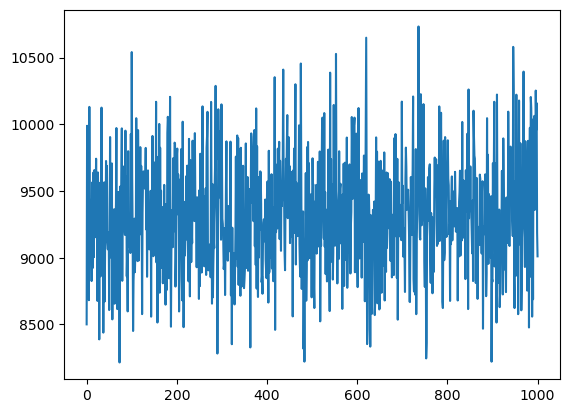

In [228]:
for i in range(num_simulations):
    balance = [8500]
    num_rolls = [0]
    #num_wins = 0
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        costo_total = iter[0] + iter[1] + iter[2] 
        balance.append(costo_total)
        num_rolls.append(num_rolls[-1]+1)
plt.plot(num_rolls,balance)  
plt.show()    


Se observa que la media ($9,313.84) es superior al costo de referencia ($8,500) y presenta baja variabilidad, con una desviación estándar de $420.30.

In [ ]:
# Estadísticas
# se obtiene la media y la desviación estándar usando numpy

media = np.mean(balance)
std = np.std(balance)

print(f"Media: ${media:.2f}")
print(f"Desviación estándar: ${std:.2f}")

Media: $9313.84
Desviación estándar: $420.30


## 4. Visualización

La gráfica corresponde a un histograma de los costos totales simulados, donde se muestra la distribución de frecuencia de los resultados obtenidos.
Se observa que la mayor concentración de valores se encuentra entre aproximadamente $9,000 y $9,700, lo que indica que ese rango representa los costos más probables del proyecto. La línea punteada negra señala el valor promedio o esperado, ubicado en $9,313.84.
La línea punteada roja representa un costo de referencia cercano a $8,500. Dado que la mayor parte de las barras se encuentra a la derecha de esta línea, se interpreta que la mayoría de las simulaciones generan costos superiores a ese valor, por lo que la probabilidad de que el costo total sea menor a $8,500 es reducida.
Asimismo, la distribución presenta cierta dispersión, con valores mínimos cercanos a $8,200 y máximos alrededor de $10,700, reflejando la variabilidad e incertidumbre de los costos del proyecto.

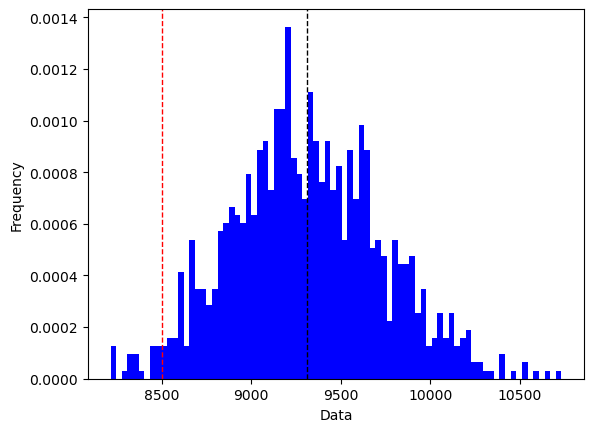

In [ ]:
# se hace un histograma de los costos totales y la línea roja es el costo total de referencia 
#y la línea negra es la media del costo total.

plt.hist(balance, density = True, bins = 80,color='blue') #density = False would make counts
plt.ylabel('Frequency') #Frequency
plt.xlabel('Data')
plt.axvline(np.mean(balance),color = 'k', linestyle='dashed',linewidth=1)
plt.axvline(costo_referencia,color = 'r', linestyle='dashed',linewidth=1)
plt.show()

In [231]:
# Se utiliza la función len() para determinar el tamaño de la muestra.
total_muestras = len(balance)
print('Número de muestras: ', total_muestras)

Número de muestras:  1001


In [232]:
# Se utiliza un ciclo for para obtener las muestras que se encuentran por debajo del costo de referencia.
costo_ok = [x for x in balance if x < costo_referencia]

In [233]:
#se utiliza la función len() para contar las muestras de los costos totales que estan por debajo del costo de referencia.
num_costo_ok = len(costo_ok)
prob_costo_ref = num_costo_ok / total_muestras
print(f'La probabilidad que el costo sea menor al costo de referencia es: {prob_costo_ref*100:.2f}%')


La probabilidad que el costo sea menor al costo de referencia es: 2.00%


In [234]:
num_costo_ok

20

In [235]:
costo_ok[:5]

[8387.295375740108,
 8437.99595935687,
 8214.10972359821,
 8450.244734298492,
 8482.46618576274]

In [236]:
#se utiliza un ciclo for para calcular los percentiles del costo total
for i in range(0,100,5):
    print('Percentil ',i,'% = ',np.percentile(balance,i))

Percentil  0 % =  8214.10972359821
Percentil  5 % =  8654.852800090992
Percentil  10 % =  8784.322650871723
Percentil  15 % =  8883.443316335635
Percentil  20 % =  8959.952504705147
Percentil  25 % =  9031.319341840948
Percentil  30 % =  9086.051893058655
Percentil  35 % =  9146.674707601327
Percentil  40 % =  9191.191076730785
Percentil  45 % =  9233.228131756385
Percentil  50 % =  9292.370867203017
Percentil  55 % =  9348.73219275585
Percentil  60 % =  9403.868003394013
Percentil  65 % =  9460.398916000342
Percentil  70 % =  9539.776172374191
Percentil  75 % =  9602.957609427995
Percentil  80 % =  9654.404565344574
Percentil  85 % =  9745.299848137316
Percentil  90 % =  9872.245412704153
Percentil  95 % =  10046.013421179645


## 6. Análisis de sensibilidad
Para el análisis de sensibilidad se usará la distribución normal en lugar de triangular para los costos de materiales, mano de obra y transporte y luego se comparara entre las dos muestras.

In [237]:
#función para obtener una muestra de todos los costos fijos determínisticos
np.random.seed(42)

def roll_dice():
   # Definición de distribuciones triangulares
    materiales = np.random.normal(loc=5000, scale=500)
    mano_obra = np.random.normal(loc=3000, scale=400)
    transporte = np.random.normal(loc=1000, scale=200)

    return materiales, mano_obra, transporte

In [239]:
num_simulations = 5000
max_num_rolls = 1000

end_balance = []

Se hace un For para hacer la simulación de 5000 iteraciones, y se tira los dados en cada iteración para obtener los costos fijos del proyecto y la suma se agrega a la lista balance en cada iteración. 

La gráfica muestra el comportamiento de las simulaciones del costo total a lo largo de las muestras generadas. Se observa una variación constante entre aproximadamente $6,000 y $11,500, lo que refleja una mayor variabilidad en comparación con escenarios más estables.

La mayor concentración de valores parece ubicarse alrededor de los $8,000 a $10,000, sugiriendo que ese rango es el más probable para el costo total. El costo total esperado esta aproximadamente en $9,000. Asimismo, no se aprecia una tendencia creciente o decreciente, sino fluctuaciones aleatorias propias de una simulación Monte Carlo.

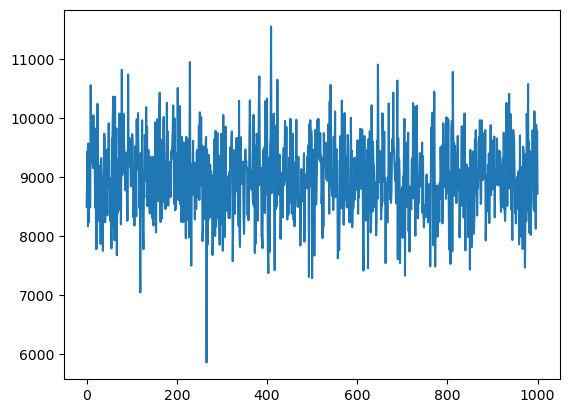

In [240]:
for i in range(num_simulations):
    balance2 = [8500]
    num_rolls = [0]
    #num_wins = 0
    while num_rolls[-1] < max_num_rolls:
        iter = roll_dice()
        costo_total = iter[0] + iter[1] + iter[2] 
        balance2.append(costo_total)
        num_rolls.append(num_rolls[-1]+1)
plt.plot(num_rolls,balance2)  
plt.show()    


El histograma muestra la distribución de frecuencia de los costos totales simulados. La mayor concentración de valores se ubica entre aproximadamente $8,400 y $9,600, lo que indica que ese rango representa los costos más probables del proyecto. La línea punteada negra señala la media cercana a $9,000, mientras que la línea roja representa el costo de referencia de $8,500. Debido a que ambas líneas se encuentran relativamente próximas, se interpreta que el costo esperado está más cercano al presupuesto de referencia.

Asimismo, la distribución presenta una forma aproximadamente normal y simétrica, con algunos valores extremos que van desde cerca de $6,000 hasta $11,500, reflejando incertidumbre en los costos.

En comparación con el histograma anterior, este presenta una media menor (más cercana a $8,500) y una mayor dispersión de los datos, ya que el rango de valores es más amplio. Mientras que en el histograma anterior los costos estaban más concentrados alrededor de $9,300 con menor variabilidad, en este caso existe mayor probabilidad de observar costos tanto más bajos como más altos. Esto sugiere un escenario con mayor riesgo e incertidumbre, aunque con un costo promedio más cercano al valor de referencia.



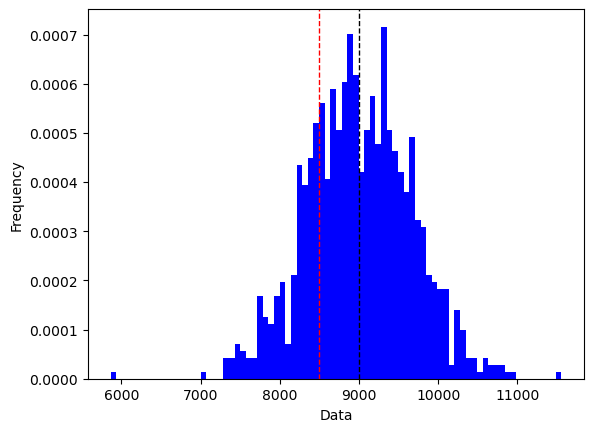

In [241]:
np.random.seed(42)
plt.hist(balance2, density = True, bins = 80,color='blue') #density = False would make counts
plt.ylabel('Frequency') #Frequency
plt.xlabel('Data')
plt.axvline(np.mean(balance2),color = 'k', linestyle='dashed',linewidth=1)
plt.axvline(costo_referencia,color = 'r', linestyle='dashed',linewidth=1)
plt.show()

In [242]:
print('Número de muestras: ', len(balance2))
total_muestras = len(balance2)
costo_ok = [x for x in balance2 if x < costo_referencia]
num_costo_ok = len(costo_ok)
prob_costo_ref= num_costo_ok/total_muestras
print(f'La probabilidad de que el costo sea menor al costo de referencia es: {prob_costo_ref*100:.2f}%')

Número de muestras:  1001
La probabilidad de que el costo sea menor al costo de referencia es: 22.78%


Se observa que esta distribución tiene mayor probabilidad (22.78%) que la anterior (2%) de tener un costo menor al costo de referencia.

En el siguiente gráfico se observan las dos distribuciones de la frequencia del costo total donde la de color naranaja tiene mayor variabilidad y mayor incertidumbre en los costos que la de color azul. Pero la media de la distribución de color naranja se acerca más al costo de referencia que la media de la distribución de color azul.

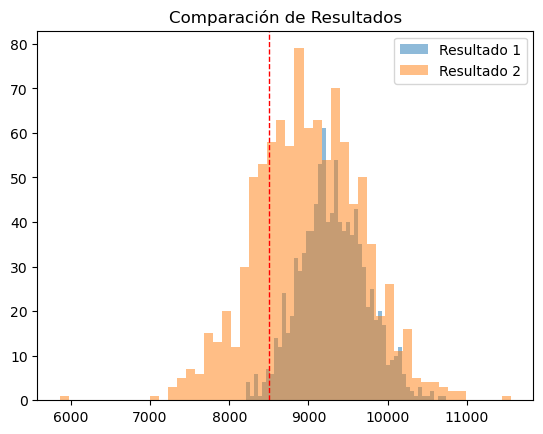

In [243]:
import numpy as np
bins = np.linspace(0,2000,10)
plt.hist(balance, bins=50, alpha=0.5,label='Resultado 1')
plt.hist(balance2, bins=50, alpha=0.5,label='Resultado 2')
plt.legend(loc='upper right')
plt.title('Comparación de Resultados')
plt.axvline(costo_referencia, color ='r',linestyle='dashed',linewidth=1)
plt.show()

## 7. Conclusiones finales

### Conclusiones

Se hizo la simulación Monte Carlo para analizar la incertidumbre asociada a los costos totales del proyecto mediante múltiples escenarios aleatorios. En un escenario, los costos presentaban una distribución triangular, mientras que en otro se modelaron con una distribución normal.

En la simulación con distribución triangular, los costos presentaron menor variabilidad y una media aproximada de $9,313.84, superior al costo de referencia de $8,500, lo que sugiere una menor probabilidad de mantenerse dentro del presupuesto establecido.

En la simulación con distribución normal, los costos mostraron mayor dispersión e incertidumbre, aunque con una media cercana a $9,000, valor más próximo al costo de referencia.

La distribución normal presentó una mayor probabilidad de generar costos totales por debajo de $8,500 en comparación con la distribución triangular, aunque también incrementó la posibilidad de valores extremos.

En términos generales, la distribución triangular refleja un escenario más estable y predecible, mientras que la distribución normal representa un entorno con mayor riesgo, pero con mejores probabilidades de ajustarse al presupuesto objetivo.


